<a href="https://colab.research.google.com/github/Shahitya-06/Fpx_Transaction_Data/blob/main/FPX_Transaction_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# FPX Transaction Spike Detection
#
# Structure:
#   PART 1 — Data Cleaning  (filter, transform, sort, validate)
#   PART 2 — EDA            (visualise, detect spikes, summarise)

import pandas as pd
import matplotlib.pyplot as plt


# ══════════════════════════════════════════════════════════════════════════════
# PART 1 — DATA CLEANING
# ══════════════════════════════════════════════════════════════════════════════

# ── Step 1: Load the raw data ─────────────────────────────────────────────────

from google.colab import files
uploaded = files.upload()

df = pd.read_csv("trnsc_daily_fpx.csv")

print("=" * 55)
print("BEFORE CLEANING")
print("=" * 55)
print(f"  Rows             : {len(df)}")
print(f"  Columns          : {list(df.columns)}")
print(f"  Missing values   : {df.isnull().sum().sum()}")
print(f"  Duplicate row    : {df.duplicated().sum()}")
print()


# ── Step 2: Filter ────────────────────────────────────────────────────────────
# Keep only model == 'both' (overall daily totals).
# Removing B2B and B2C avoids counting the same transactions multiple times.

df = df[df["model"] == "both"]


# ── Step 3: Transform ─────────────────────────────────────────────────────────
# Convert the date column from plain text → proper date objects.
# Without this, Python treats dates as strings and can't sort or plot them.

df["date"] = pd.to_datetime(df["date"])

# ── Cleaning output: before vs after summary table ────────────────────────────

print("=" * 55)
print("AFTER CLEANING — SUMMARY")
print("=" * 55)
print(f"  Rows remaining   : {len(df)}")
print(f"  Missing values   : {df.isnull().sum().sum()}")
print(f"  Duplicate dates  : {df.duplicated(subset='date').sum()}")
print(f"  Date range       : {df['date'].min().date()} → {df['date'].max().date()}")
print(f"  Volume range     : {int(df['volume'].min()):,} → {int(df['volume'].max()):,}")
print()
print("First 5 rows after cleaning:")
print(df[["date", "volume", "value"]].head().to_string(index=False))
print()

Saving trnsc_daily_fpx.csv to trnsc_daily_fpx.csv
BEFORE CLEANING
  Rows             : 6846
  Columns          : ['date', 'model', 'volume', 'value']
  Missing values   : 0
  Duplicate row    : 0

AFTER CLEANING — SUMMARY
  Rows remaining   : 2282
  Missing values   : 0
  Duplicate dates  : 0
  Date range       : 2020-01-01 → 2026-04-02
  Volume range     : 405,247 → 4,096,942

First 5 rows after cleaning:
      date  volume        value
2020-01-01  659215 2.420527e+08
2020-01-02  697383 2.038087e+08
2020-01-03  715381 3.094553e+08
2020-01-04  629496 2.629483e+08
2020-01-05  568361 1.181617e+08



EDA — SUMMARY STATISTICS
  Mean daily volume   : 1,933,422
  Median daily volume : 1,910,826
  Highest single day  : 4,096,942  (2026-03-03)
  Lowest single day   : 405,247  (2020-01-26)
  Total spike days    : 13

Spike days:
-------------------------------------------------------
  2020-11-11  |   2,702,138 txns  |  2.15× avg
  2020-11-12  |   2,459,590 txns  |  1.89× avg
  2021-11-11  |   2,983,913 txns  |  1.68× avg
  2020-09-09  |   1,815,399 txns  |  1.67× avg
  2020-12-12  |   2,121,552 txns  |  1.67× avg
  2020-09-10  |   1,788,305 txns  |  1.61× avg
  2021-09-09  |   3,181,370 txns  |  1.61× avg
  2021-07-07  |   2,874,429 txns  |  1.55× avg
  2025-07-01  |   3,808,807 txns  |  1.54× avg
  2021-12-12  |   2,788,519 txns  |  1.54× avg
  2021-06-06  |   2,605,924 txns  |  1.53× avg
  2020-03-27  |   1,047,460 txns  |  1.51× avg
  2020-07-07  |   1,522,284 txns  |  1.51× avg



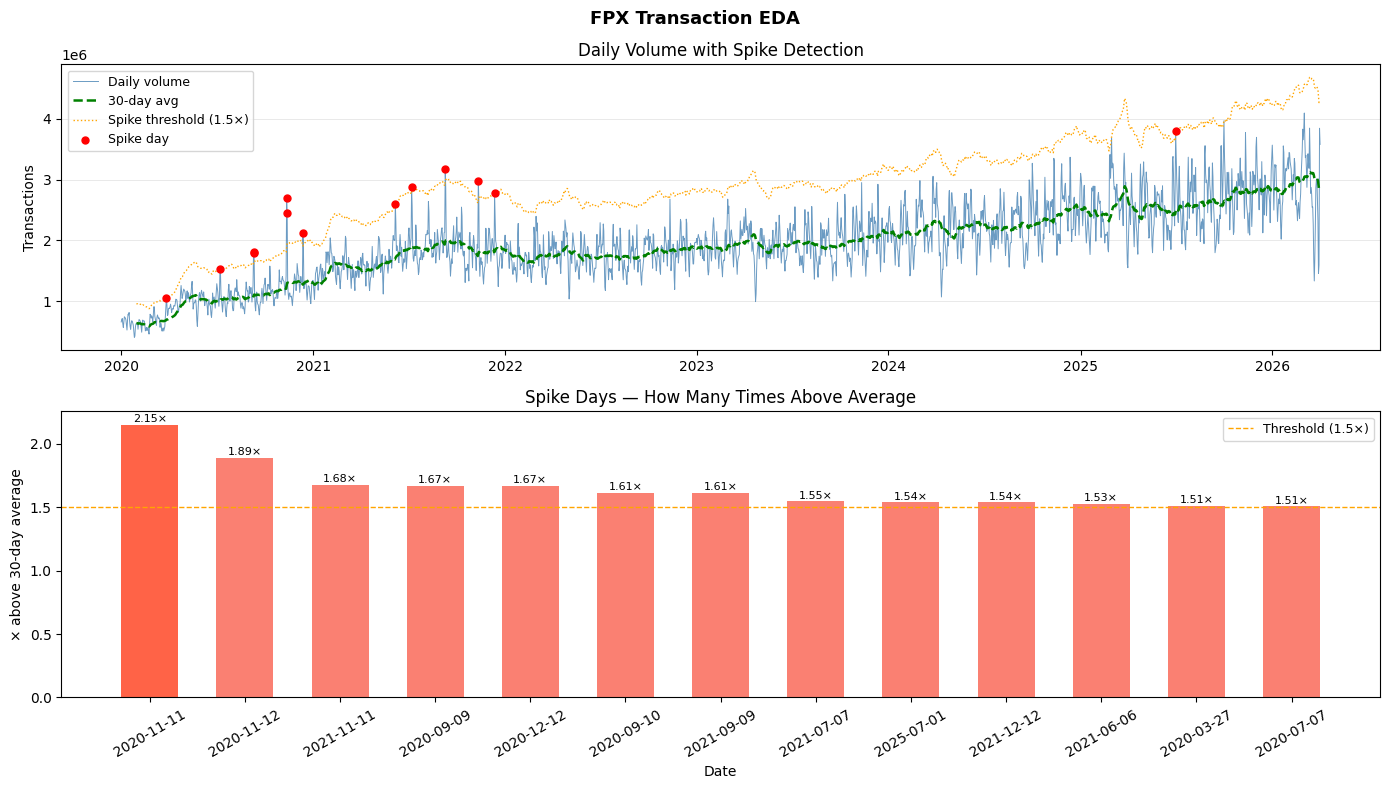

EDA chart saved: eda_output.png
Spike list saved: fpx_spike_days.csv
Done!


In [2]:
# ══════════════════════════════════════════════════════════════════════════════
# PART 2 — EXPLORATORY DATA ANALYSIS (EDA)
# ══════════════════════════════════════════════════════════════════════════════

# Calculate rolling average and flag spikes

WINDOW    = 30    # how many past days to average over
THRESHOLD = 1.5   # how many times above average counts as a spike

df["rolling_avg"]     = df["volume"].rolling(window=WINDOW).mean()
df["times_above_avg"] = df["volume"] / df["rolling_avg"]
df["is_spike"]        = df["volume"] > (df["rolling_avg"] * THRESHOLD)

spikes = df[df["is_spike"] == True].copy()

#  EDA output 1: printed summary statistics

print("=" * 55)
print("EDA — SUMMARY STATISTICS")
print("=" * 55)
print(f"  Mean daily volume   : {int(df['volume'].mean()):,}")
print(f"  Median daily volume : {int(df['volume'].median()):,}")
print(f"  Highest single day  : {int(df['volume'].max()):,}  ({df.loc[df['volume'].idxmax(), 'date'].date()})")
print(f"  Lowest single day   : {int(df['volume'].min()):,}  ({df.loc[df['volume'].idxmin(), 'date'].date()})")
print(f"  Total spike days    : {len(spikes)}")
print()
print(f"Spike days:")
print("-" * 55)
top_spikes = spikes.sort_values("times_above_avg", ascending=False).head(13)
for _, row in top_spikes.iterrows():
    print(f"  {row['date'].date()}  |  {int(row['volume']):>10,} txns  |  {row['times_above_avg']:.2f}× avg")
print()

# EDA output 2: two-panel chart

fig, axes = plt.subplots(2, 1, figsize=(14, 8))
fig.suptitle("FPX Transaction EDA", fontsize=13, fontweight="bold")

# Top panel — full daily volume with rolling average + spike markers
axes[0].plot(df["date"], df["volume"],
             color="steelblue", linewidth=0.7, alpha=0.8, label="Daily volume")
axes[0].plot(df["date"], df["rolling_avg"],
             color="green", linewidth=1.8, linestyle="--", label="30-day avg")
axes[0].plot(df["date"], df["rolling_avg"] * THRESHOLD,
             color="orange", linewidth=1, linestyle=":", label="Spike threshold (1.5×)")
axes[0].scatter(spikes["date"], spikes["volume"],
                color="red", s=25, zorder=5, label="Spike day")
axes[0].set_title("Daily Volume with Spike Detection")
axes[0].set_ylabel("Transactions")
axes[0].legend(fontsize=9)
axes[0].grid(axis="y", linewidth=0.4, alpha=0.5)

# Bottom panel — bar chart of top 10 spike days
top10 = spikes.sort_values("times_above_avg", ascending=False).head(13)
bar_labels = top10["date"].dt.strftime("%Y-%m-%d")
bar_colors = ["tomato" if x >= 2.0 else "salmon" for x in top10["times_above_avg"]]
bars = axes[1].bar(bar_labels, top10["times_above_avg"], color=bar_colors, width=0.6)
axes[1].axhline(y=THRESHOLD, color="orange", linestyle="--", linewidth=1,
                label=f"Threshold ({THRESHOLD}×)")
axes[1].set_title("Spike Days — How Many Times Above Average")
axes[1].set_ylabel("× above 30-day average")
axes[1].set_xlabel("Date")
axes[1].tick_params(axis="x", rotation=30)
axes[1].legend(fontsize=9)
for bar, val in zip(bars, top10["times_above_avg"]):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.02,
                 f"{val:.2f}×", ha="center", fontsize=8)

plt.tight_layout()
plt.savefig("eda_output.png", dpi=150, bbox_inches="tight")
plt.show()
print("EDA chart saved: eda_output.png")

# ── Save spike list ───────────────────────────────────────────────────────────

spikes[["date", "volume", "rolling_avg", "times_above_avg"]].to_csv(
    "fpx_spike_days.csv", index=False
)
print("Spike list saved: fpx_spike_days.csv")
print("Done!")

# Data Modelling

FPX TRANSACTION DATA — LOADED
Total records : 2282
Date range    : 2020-01-01 to 2026-04-02
Columns       : ['date', 'model', 'volume', 'value']

MODEL 1: MOVING AVERAGE (Statistical Model)
Objective 1 — Identify patterns & forecast volume
7-Day MA  (latest) : 2,687,115 transactions
30-Day MA (latest) : 2,843,934 transactions
30-Day Forecast    : 2,687,115 transactions/day (based on 7-day MA)

MODEL 2: Z-SCORE (Statistical Model)
Objective 1 — Classify normal vs anomaly days
Days classified as NORMAL  : 2160 (94.7%)
Days classified as ANOMALY : 122 (5.3%)

Top 5 anomaly days:
      date  volume  z_score   label
2026-03-03 4096942 3.430303 ANOMALY
2025-10-01 3969078 3.227572 ANOMALY
2026-03-13 3848545 3.036464 ANOMALY
2026-04-01 3846276 3.032867 ANOMALY
2026-02-28 3831219 3.008994 ANOMALY

MODEL 3: LINEAR REGRESSION *** MAIN ML MODEL ***
TYPE    : Machine Learning — Regression & Forecasting
Objective 2 & 3 — Forecast future FPX transaction values
Training samples : 1824 days (80%)
Testi

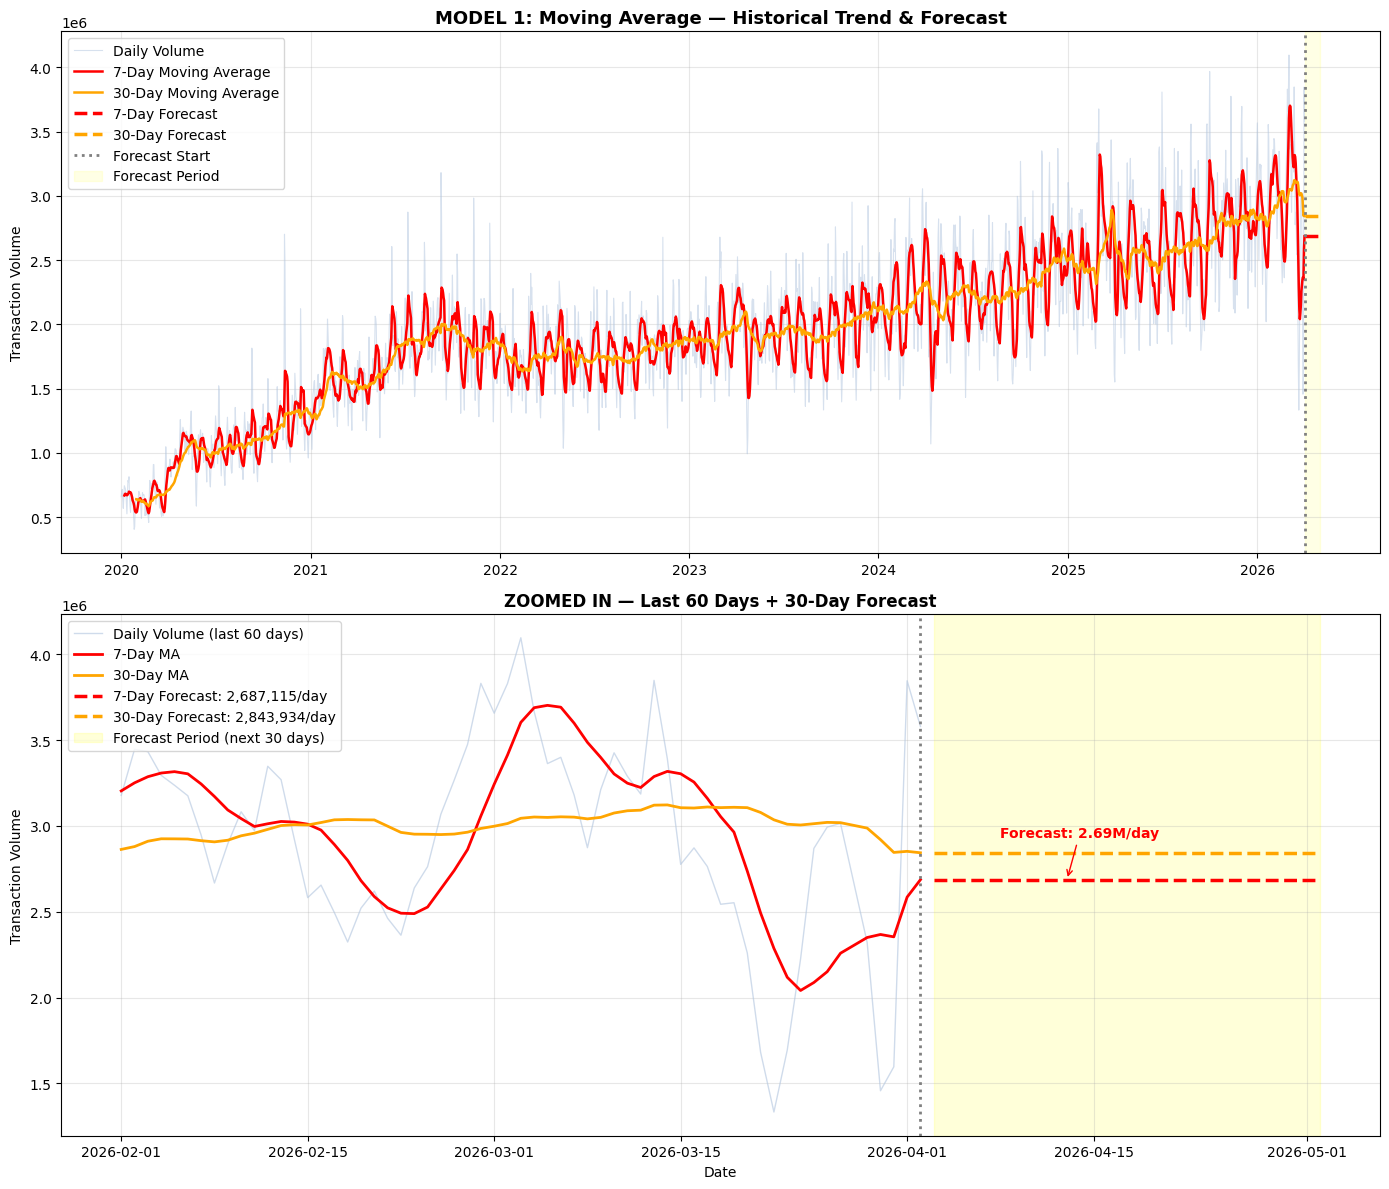


CHART 1 — MODEL 1: MOVING AVERAGE
--------------------------------------------------
WHAT IT DOES: Forecasts future FPX transaction volume
HOW: Averages the last 7 or 30 days and projects forward
FORECAST: 2,687,115 transactions/day for next 30 days
Top chart   : full historical trend 2020-2026
Bottom chart: zoomed in — last 60 days + 30-day forecast
Yellow zone : the 30-day forecast window
Dashed lines: forecasted values going forward


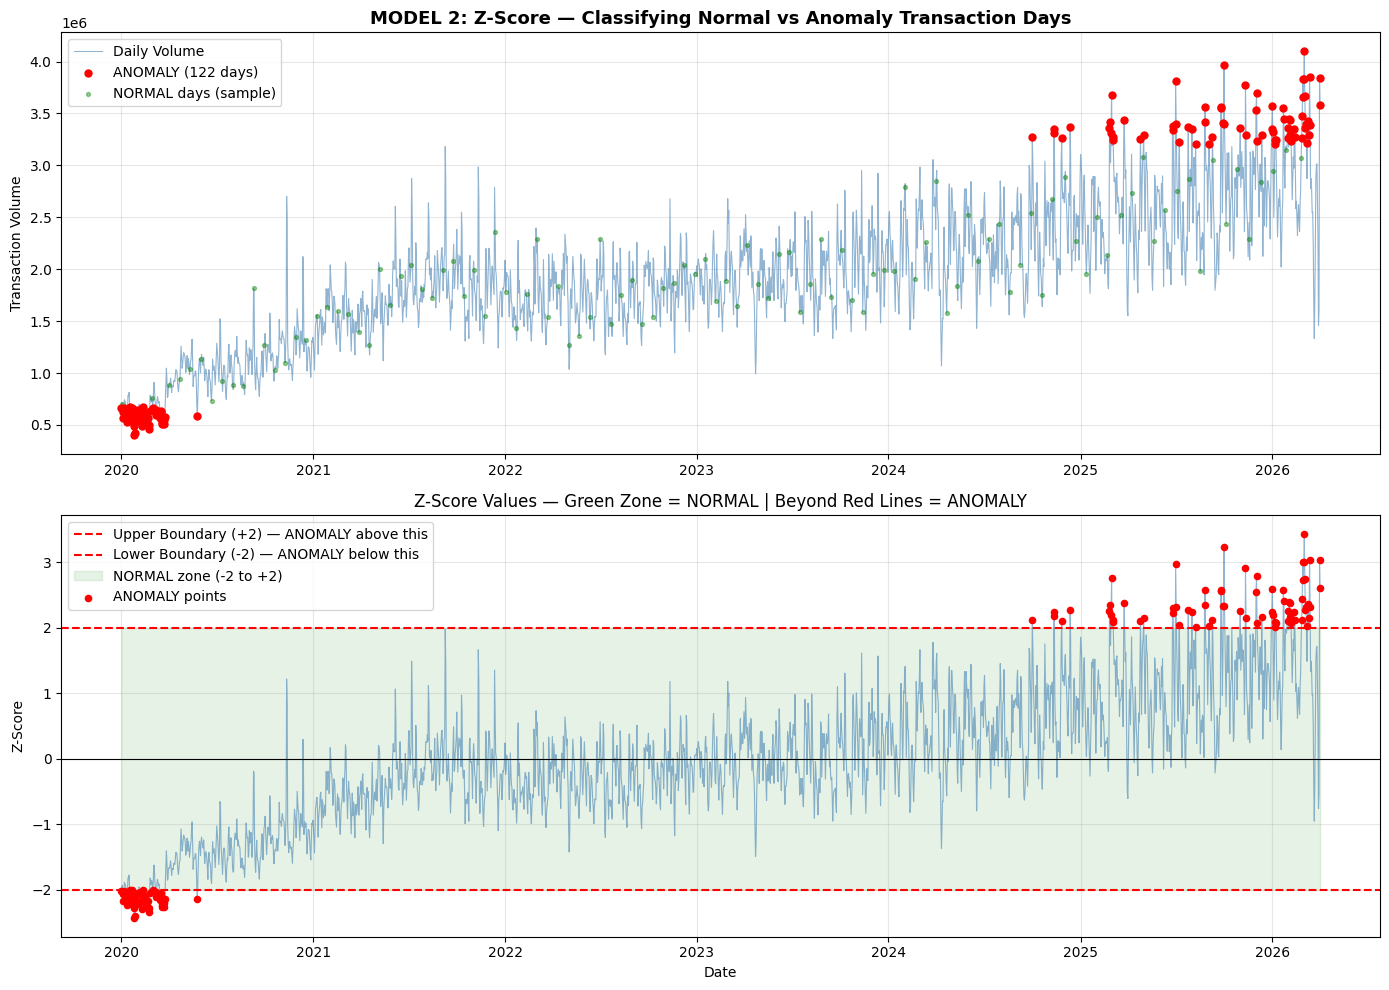


CHART 2 — MODEL 2: Z-SCORE ANOMALY DETECTION
--------------------------------------------------
WHAT IT DOES: Classifies every day as NORMAL or ANOMALY
HOW: Measures how far each day is from the average
     Z-Score within -2 to +2 = NORMAL
     Z-Score beyond -2 or +2 = ANOMALY
RESULT: 2160 NORMAL days | 122 ANOMALY days
Top chart   : red dots = anomaly days, green = normal days
Bottom chart: green zone = normal classification boundary
Anomalies caused by MCO lockdowns or festive season spikes


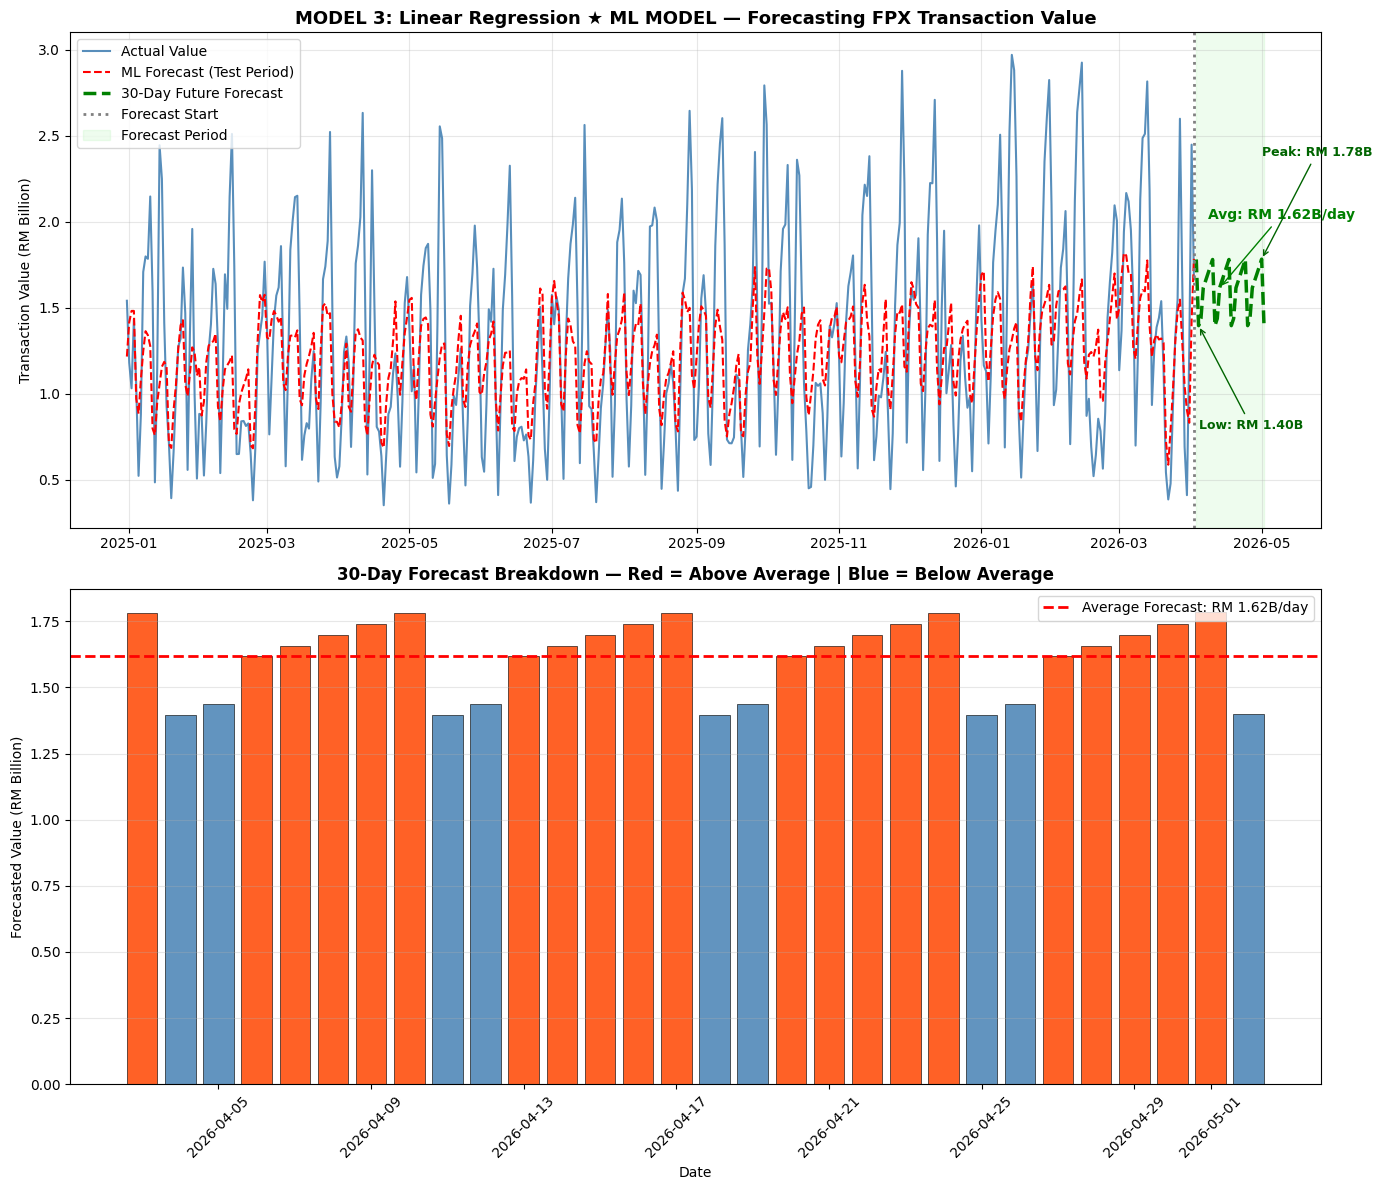


CHART 3 — MODEL 3: LINEAR REGRESSION ★ MAIN ML MODEL
--------------------------------------------------
WHAT IT DOES: Forecasts future FPX transaction VALUE (RM)
HOW: Learns the mathematical relationship between volume,
     day of week, month, year and transaction value.
     Applies that relationship to future dates to forecast RM.

MODEL ACCURACY:
  R²   = 0.3549 — model explains 35.5% of value variation
  MAPE = 31.27% — average forecast error

30-DAY FORECAST:
  Average : RM 1,616,847,630/day
  Highest : RM 1,783,468,762 on 2026-05-01
  Lowest  : RM 1,396,874,299 on 2026-04-04
Top chart   : actual vs ML forecast + green 30-day future forecast
Bottom chart: daily forecast breakdown — red = high activity days


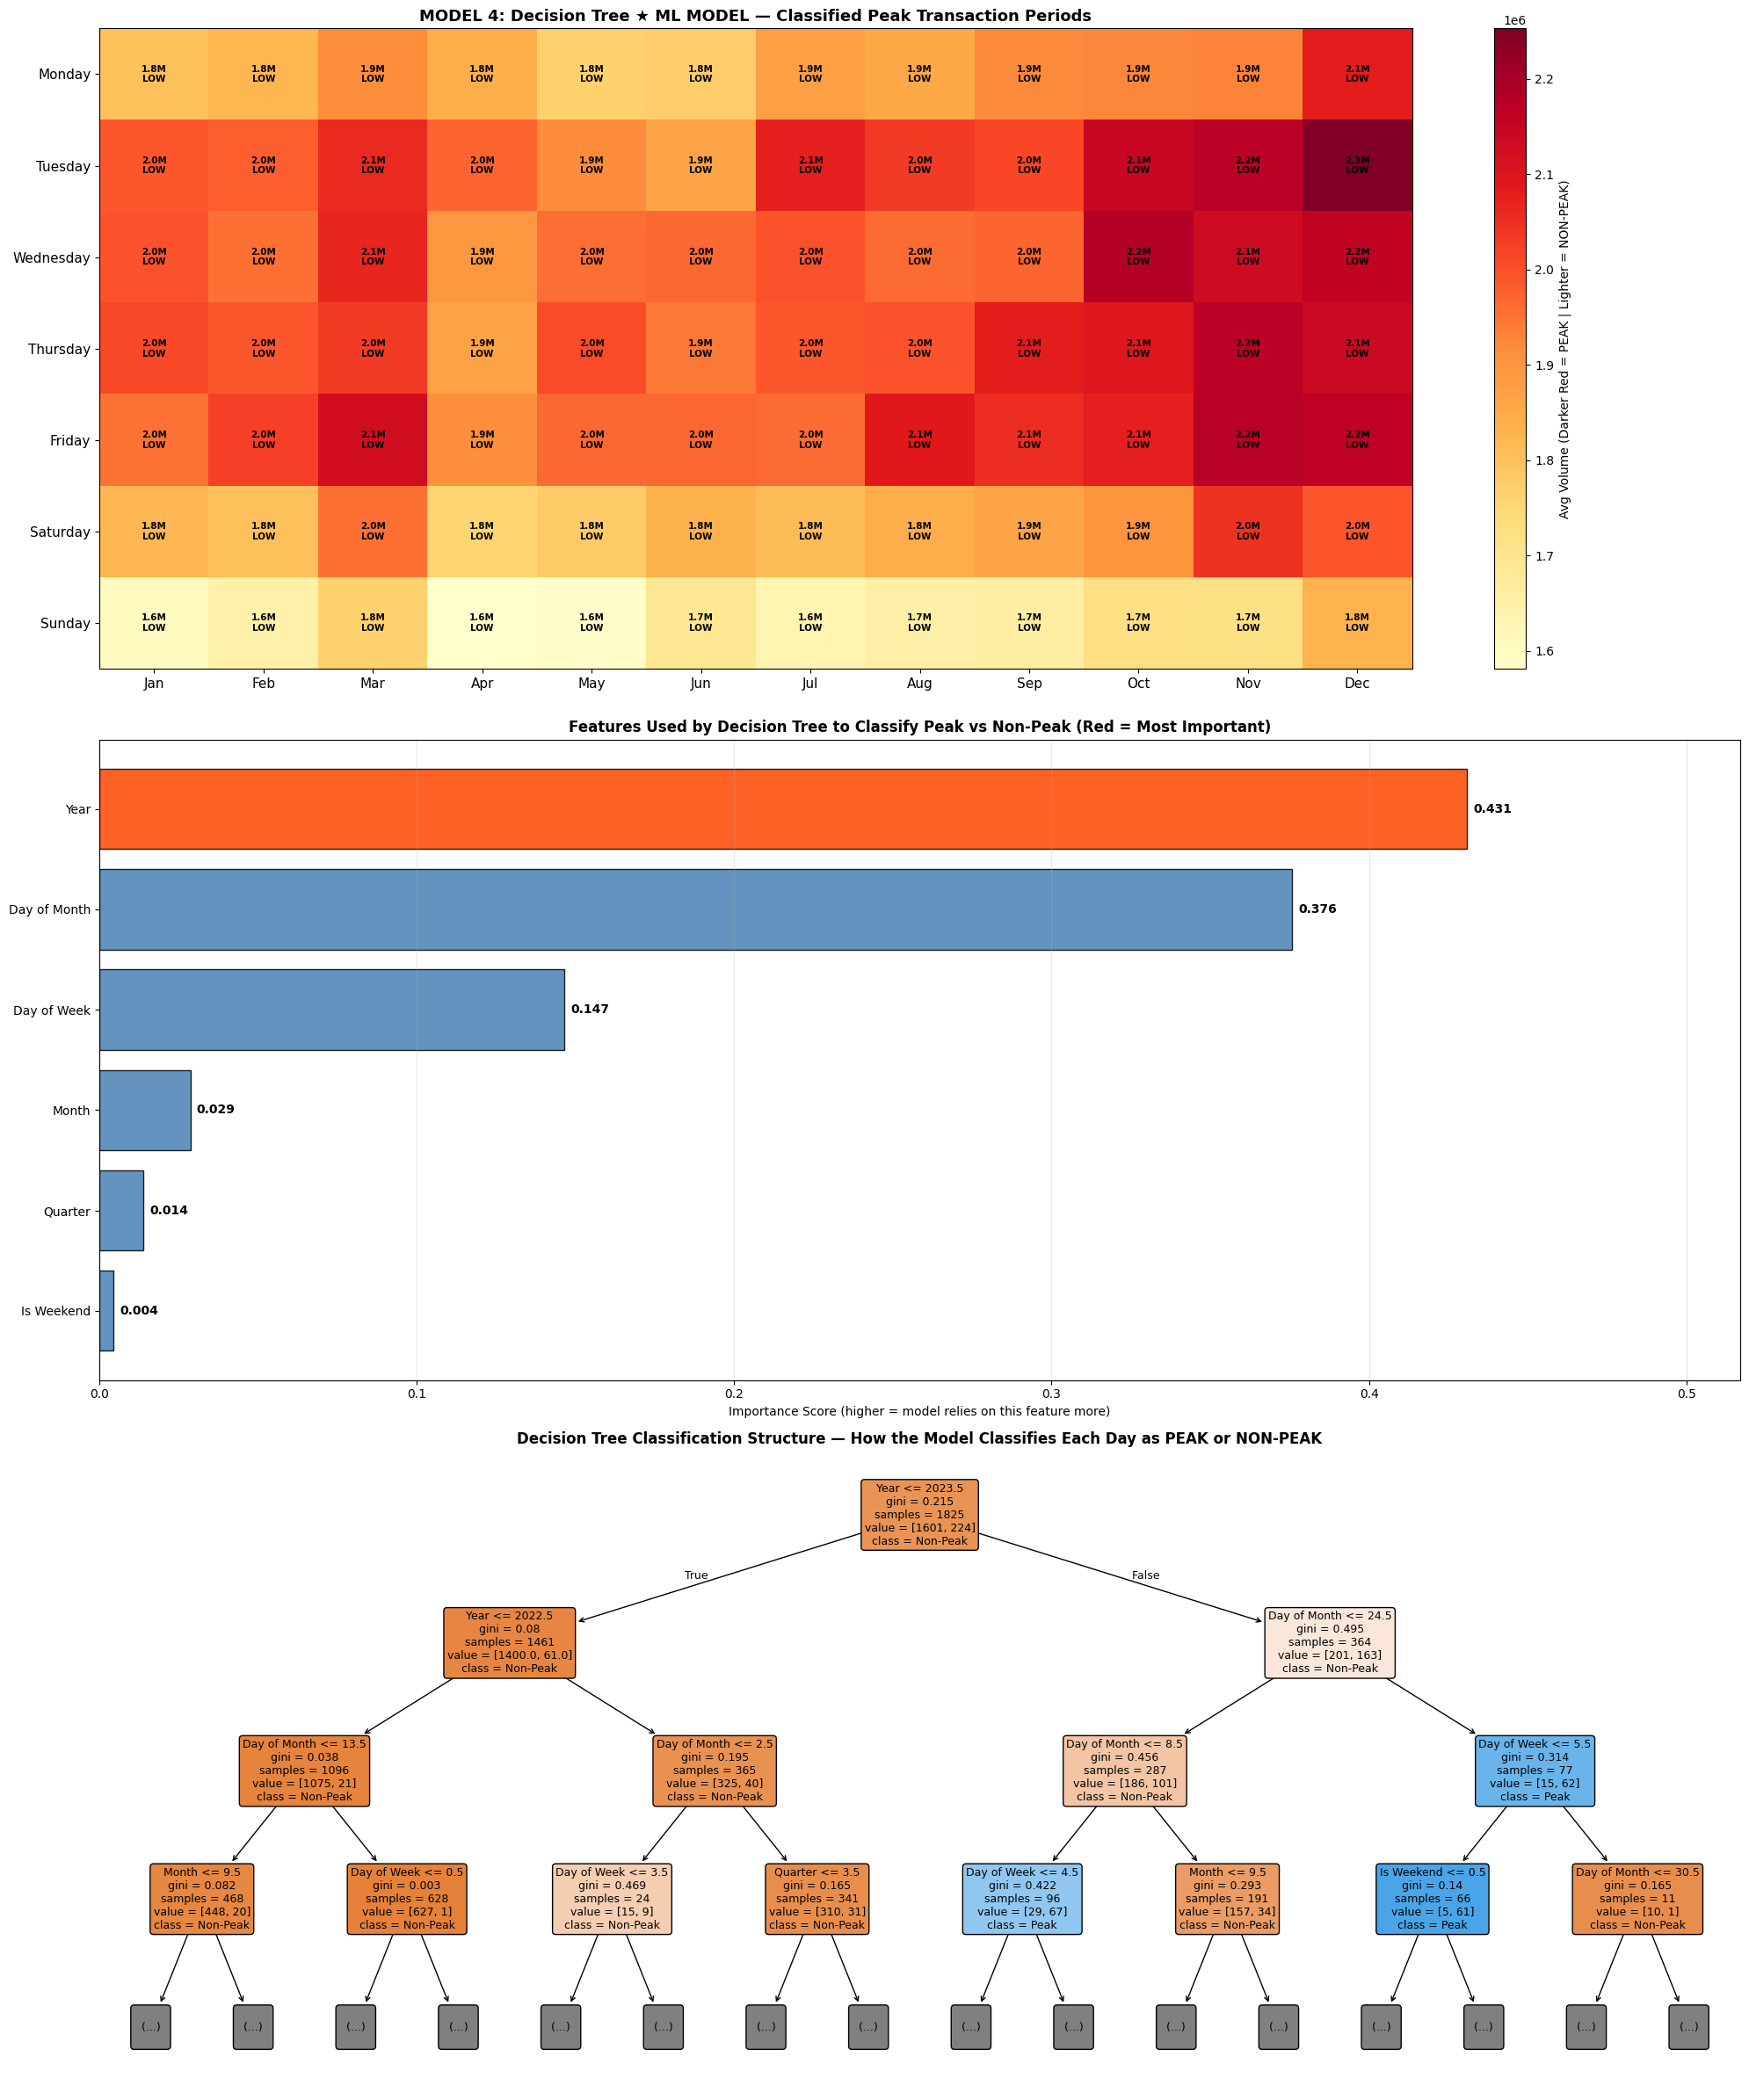


CHART 4 — MODEL 4: DECISION TREE ★ MAIN ML MODEL
--------------------------------------------------
WHAT IT DOES: Classifies every day as PEAK or NON-PEAK
HOW: Learns from historical patterns which combinations
     of day, month and quarter result in peak periods.
     Asks yes/no questions to arrive at a classification.

CLASSIFICATION THRESHOLD: 2,309,049 transactions
  Peak days     : 571 (25.0%)
  Non-peak days : 1711 (75.0%)
Top chart   : heatmap — darker red = classified as PEAK period
             ★ PEAK label shows which day/month combos are peak
Middle chart: red bar = most important feature for classification
Bottom chart: the actual decision tree showing yes/no questions
             Orange = classified PEAK | Blue = classified NON-PEAK

ALL MODELS COMPLETE
STATISTICAL MODELS:
  Model 1: Moving Average    — forecasts future volume
  Model 2: Z-Score           — classifies normal vs anomaly

ML MODELS (MAIN):
  Model 3: Linear Regression — forecasts future RM value
  Model 

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, classification_report
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# LOAD & PREPARE DATA
# ============================================================
df = pd.read_csv('trnsc_daily_fpx.csv')
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['model', 'date']).reset_index(drop=True)
df_both = df[df['model'] == 'both'].copy().reset_index(drop=True)

print('='*60)
print('FPX TRANSACTION DATA — LOADED')
print('='*60)
print(f'Total records : {len(df_both)}')
print(f'Date range    : {df_both["date"].min().date()} to {df_both["date"].max().date()}')
print(f'Columns       : {list(df_both.columns)}')


# ============================================================
# MODEL 1: MOVING AVERAGE (Statistical Support Model)
# Objective 1 — Identify patterns in FPX transactions
# ============================================================
df_ma = df_both.copy()
df_ma['MA_7']  = df_ma['volume'].rolling(window=7).mean()
df_ma['MA_30'] = df_ma['volume'].rolling(window=30).mean()

last_date     = df_ma['date'].iloc[-1]
future_dates  = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=30)
ma7_forecast  = np.full(30, df_ma['MA_7'].iloc[-1])
ma30_forecast = np.full(30, df_ma['MA_30'].iloc[-1])

print('\n' + '='*60)
print('MODEL 1: MOVING AVERAGE (Statistical Model)')
print('Objective 1 — Identify patterns & forecast volume')
print('='*60)
print(f'7-Day MA  (latest) : {df_ma["MA_7"].iloc[-1]:,.0f} transactions')
print(f'30-Day MA (latest) : {df_ma["MA_30"].iloc[-1]:,.0f} transactions')
print(f'30-Day Forecast    : {ma7_forecast[0]:,.0f} transactions/day (based on 7-day MA)')


# ============================================================
# MODEL 2: Z-SCORE (Statistical Support Model)
# Objective 1 — Detect and classify anomalies
# ============================================================
df_zscore = df_both.copy()
df_zscore['z_score'] = (df_zscore['volume'] - df_zscore['volume'].mean()) / df_zscore['volume'].std()
df_zscore['anomaly'] = df_zscore['z_score'].abs() > 2
df_zscore['label']   = df_zscore['anomaly'].map({True: 'ANOMALY', False: 'NORMAL'})
anomalies = df_zscore[df_zscore['anomaly'] == True]
normal_days = df_zscore[~df_zscore['anomaly']]

print('\n' + '='*60)
print('MODEL 2: Z-SCORE (Statistical Model)')
print('Objective 1 — Classify normal vs anomaly days')
print('='*60)
print(f'Days classified as NORMAL  : {len(normal_days)} ({len(normal_days)/len(df_zscore)*100:.1f}%)')
print(f'Days classified as ANOMALY : {len(anomalies)} ({len(anomalies)/len(df_zscore)*100:.1f}%)')
print(f'\nTop 5 anomaly days:')
print(anomalies.nlargest(5, 'volume')[['date', 'volume', 'z_score', 'label']].to_string(index=False))


# ============================================================
# MODEL 3: LINEAR REGRESSION (Main ML Model — Forecasting)
# Objective 2 & 3 — Forecast future transaction values
# ============================================================
df_lr = df_both.copy()
df_lr['day_of_week']  = df_lr['date'].dt.dayofweek
df_lr['month']        = df_lr['date'].dt.month
df_lr['year']         = df_lr['date'].dt.year
df_lr['is_weekend']   = (df_lr['day_of_week'] >= 5).astype(int)
df_lr['volume_lag1']  = df_lr['volume'].shift(1)
df_lr = df_lr.dropna().reset_index(drop=True)

features_lr = ['volume', 'day_of_week', 'month', 'year', 'is_weekend', 'volume_lag1']
X_lr = df_lr[features_lr]
y_lr = df_lr['value']
split_lr = int(len(df_lr) * 0.8)
X_train_lr, X_test_lr = X_lr.iloc[:split_lr], X_lr.iloc[split_lr:]
y_train_lr, y_test_lr = y_lr.iloc[:split_lr], y_lr.iloc[split_lr:]
test_dates_lr = df_lr['date'].iloc[split_lr:].values

lr_model = LinearRegression()
lr_model.fit(X_train_lr, y_train_lr)
y_pred_lr = lr_model.predict(X_test_lr)

future_lr_dates = pd.date_range(start=df_lr['date'].iloc[-1] + pd.Timedelta(days=1), periods=30)
future_lr_df = pd.DataFrame({
    'volume'      : np.full(30, df_lr['volume'].iloc[-1]),
    'day_of_week' : future_lr_dates.dayofweek,
    'month'       : future_lr_dates.month,
    'year'        : future_lr_dates.year,
    'is_weekend'  : (future_lr_dates.dayofweek >= 5).astype(int),
    'volume_lag1' : np.full(30, df_lr['volume'].iloc[-1])
})
future_lr_pred = lr_model.predict(future_lr_df)

mae_lr  = mean_absolute_error(y_test_lr, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test_lr, y_pred_lr))
r2_lr   = r2_score(y_test_lr, y_pred_lr)
mape_lr = np.mean(np.abs((y_test_lr - y_pred_lr) / y_test_lr)) * 100
corr    = df_lr['volume'].corr(df_lr['value'])

print('\n' + '='*60)
print('MODEL 3: LINEAR REGRESSION *** MAIN ML MODEL ***')
print('TYPE    : Machine Learning — Regression & Forecasting')
print('Objective 2 & 3 — Forecast future FPX transaction values')
print('='*60)
print(f'Training samples : {len(X_train_lr)} days (80%)')
print(f'Testing samples  : {len(X_test_lr)} days (20%)')
print(f'\nMODEL PERFORMANCE:')
print(f'  MAE  : RM {mae_lr:,.0f}  — average forecast error per day')
print(f'  RMSE : RM {rmse_lr:,.0f}  — error penalising large mistakes')
print(f'  MAPE : {mape_lr:.2f}%         — percentage forecast error')
print(f'  R²   : {r2_lr:.4f}         — {r2_lr*100:.1f}% of variation explained by model')
print(f'  Correlation (volume vs value): {corr:.4f}')
print(f'\n30-DAY FORECAST RESULTS:')
print(f'  Average : RM {future_lr_pred.mean():,.0f}/day')
print(f'  Highest : RM {future_lr_pred.max():,.0f} on {future_lr_dates[future_lr_pred.argmax()].date()}')
print(f'  Lowest  : RM {future_lr_pred.min():,.0f} on {future_lr_dates[future_lr_pred.argmin()].date()}')
print(f'\nFirst 7 days forecasted:')
for d, v in zip(future_lr_dates[:7], future_lr_pred[:7]):
    print(f'  {d.date()} : RM {v:,.0f}')


# ============================================================
# MODEL 4: DECISION TREE (Main ML Model — Classification)
# Objective 2 — Classify and predict peak transaction periods
# ============================================================
df_dt = df_both.copy()
threshold = df_dt['volume'].quantile(0.75)
df_dt['is_peak']      = (df_dt['volume'] >= threshold).astype(int)
df_dt['day_of_week']  = df_dt['date'].dt.dayofweek
df_dt['day_of_month'] = df_dt['date'].dt.day
df_dt['month']        = df_dt['date'].dt.month
df_dt['quarter']      = df_dt['date'].dt.quarter
df_dt['year']         = df_dt['date'].dt.year
df_dt['is_weekend']   = (df_dt['day_of_week'] >= 5).astype(int)

features_dt = ['day_of_week', 'day_of_month', 'month', 'quarter', 'year', 'is_weekend']
feature_labels = {
    'day_of_week' : 'Day of Week',
    'day_of_month': 'Day of Month',
    'month'       : 'Month',
    'quarter'     : 'Quarter',
    'year'        : 'Year',
    'is_weekend'  : 'Is Weekend'
}

X_dt = df_dt[features_dt]
y_dt = df_dt['is_peak']
split_dt = int(len(df_dt) * 0.8)
X_train_dt, X_test_dt = X_dt.iloc[:split_dt], X_dt.iloc[split_dt:]
y_train_dt, y_test_dt = y_dt.iloc[:split_dt], y_dt.iloc[split_dt:]

dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train_dt, y_train_dt)
y_pred_dt = dt_model.predict(X_test_dt)
test_dates_dt = df_dt['date'].iloc[split_dt:].values

print('\n' + '='*60)
print('MODEL 4: DECISION TREE *** MAIN ML MODEL ***')
print('TYPE    : Machine Learning — Classification')
print('Objective 2 — Classify & predict peak transaction periods')
print('='*60)
print(f'Peak threshold : {threshold:,.0f} transactions (75th percentile)')
print(f'Peak days      : {df_dt["is_peak"].sum()} ({df_dt["is_peak"].sum()/len(df_dt)*100:.1f}%)')
print(f'Non-peak days  : {(df_dt["is_peak"]==0).sum()} ({(df_dt["is_peak"]==0).sum()/len(df_dt)*100:.1f}%)')
print(f'\nCLASSIFICATION RESULTS:')
print(classification_report(y_test_dt, y_pred_dt, target_names=['Non-Peak', 'Peak']))


# ============================================================
# ALL CHARTS — DISPLAYED ONCE AT THE END
# ============================================================
print('\n' + '='*60)
print('GENERATING ALL CHARTS...')
print('='*60)


# --- CHART 1: Moving Average ---
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# Top — Full trend
axes[0].plot(df_ma['date'], df_ma['volume'], color='lightsteelblue', linewidth=0.8, alpha=0.5, label='Daily Volume')
axes[0].plot(df_ma['date'], df_ma['MA_7'],  color='red',    linewidth=1.8, label='7-Day Moving Average')
axes[0].plot(df_ma['date'], df_ma['MA_30'], color='orange', linewidth=1.8, label='30-Day Moving Average')
axes[0].plot(future_dates, ma7_forecast,  color='red',    linewidth=2.5, linestyle='--', label='7-Day Forecast')
axes[0].plot(future_dates, ma30_forecast, color='orange', linewidth=2.5, linestyle='--', label='30-Day Forecast')
axes[0].axvline(x=last_date, color='gray', linestyle=':', linewidth=2, label='Forecast Start')
axes[0].axvspan(future_dates[0], future_dates[-1], alpha=0.1, color='yellow', label='Forecast Period')
axes[0].set_title('MODEL 1: Moving Average — Historical Trend & Forecast', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Transaction Volume')
axes[0].legend(loc='upper left')
axes[0].grid(True, alpha=0.3)

# Bottom — Zoomed into forecast
zoom_data = df_ma[df_ma['date'] >= df_ma['date'].iloc[-60]]
axes[1].plot(zoom_data['date'], zoom_data['volume'], color='lightsteelblue', linewidth=1, alpha=0.6, label='Daily Volume (last 60 days)')
axes[1].plot(zoom_data['date'], zoom_data['MA_7'],  color='red',    linewidth=2, label='7-Day MA')
axes[1].plot(zoom_data['date'], zoom_data['MA_30'], color='orange', linewidth=2, label='30-Day MA')
axes[1].plot(future_dates, ma7_forecast,  color='red',    linewidth=2.5, linestyle='--', label=f'7-Day Forecast: {ma7_forecast[0]:,.0f}/day')
axes[1].plot(future_dates, ma30_forecast, color='orange', linewidth=2.5, linestyle='--', label=f'30-Day Forecast: {ma30_forecast[0]:,.0f}/day')
axes[1].axvline(x=last_date, color='gray', linestyle=':', linewidth=2)
axes[1].axvspan(future_dates[0], future_dates[-1], alpha=0.15, color='yellow', label='Forecast Period (next 30 days)')
axes[1].annotate(f'Forecast: {ma7_forecast[0]/1e6:.2f}M/day',
                xy=(future_dates[10], ma7_forecast[0]),
                xytext=(future_dates[5], ma7_forecast[0] + 250000),
                fontsize=10, color='red', fontweight='bold',
                arrowprops=dict(arrowstyle='->', color='red'))
axes[1].set_title('ZOOMED IN — Last 60 Days + 30-Day Forecast', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Transaction Volume')
axes[1].set_xlabel('Date')
axes[1].legend(loc='upper left')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('model1_moving_average.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nCHART 1 — MODEL 1: MOVING AVERAGE')
print('-'*50)
print('WHAT IT DOES: Forecasts future FPX transaction volume')
print('HOW: Averages the last 7 or 30 days and projects forward')
print(f'FORECAST: {ma7_forecast[0]:,.0f} transactions/day for next 30 days')
print('Top chart   : full historical trend 2020-2026')
print('Bottom chart: zoomed in — last 60 days + 30-day forecast')
print('Yellow zone : the 30-day forecast window')
print('Dashed lines: forecasted values going forward')


# --- CHART 2: Z-Score ---
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

axes[0].plot(df_zscore['date'], df_zscore['volume'], color='steelblue', linewidth=0.8, alpha=0.6, label='Daily Volume')
axes[0].scatter(anomalies['date'], anomalies['volume'], color='red', s=25, zorder=5, label=f'ANOMALY ({len(anomalies)} days)')
axes[0].scatter(normal_days['date'].iloc[::20], normal_days['volume'].iloc[::20], color='green', s=8, zorder=4, alpha=0.4, label='NORMAL days (sample)')
axes[0].set_title('MODEL 2: Z-Score — Classifying Normal vs Anomaly Transaction Days', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Transaction Volume')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(df_zscore['date'], df_zscore['z_score'], color='steelblue', linewidth=0.8, alpha=0.6)
axes[1].axhline(y=2,  color='red',   linestyle='--', linewidth=1.5, label='Upper Boundary (+2) — ANOMALY above this')
axes[1].axhline(y=-2, color='red',   linestyle='--', linewidth=1.5, label='Lower Boundary (-2) — ANOMALY below this')
axes[1].axhline(y=0,  color='black', linestyle='-',  linewidth=0.8)
axes[1].fill_between(df_zscore['date'], -2, 2, alpha=0.1, color='green', label='NORMAL zone (-2 to +2)')
axes[1].scatter(anomalies['date'], anomalies['z_score'], color='red', s=20, zorder=5, label='ANOMALY points')
axes[1].set_title('Z-Score Values — Green Zone = NORMAL | Beyond Red Lines = ANOMALY', fontsize=12)
axes[1].set_ylabel('Z-Score')
axes[1].set_xlabel('Date')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('model2_zscore_anomaly.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nCHART 2 — MODEL 2: Z-SCORE ANOMALY DETECTION')
print('-'*50)
print('WHAT IT DOES: Classifies every day as NORMAL or ANOMALY')
print('HOW: Measures how far each day is from the average')
print('     Z-Score within -2 to +2 = NORMAL')
print('     Z-Score beyond -2 or +2 = ANOMALY')
print(f'RESULT: {len(normal_days)} NORMAL days | {len(anomalies)} ANOMALY days')
print('Top chart   : red dots = anomaly days, green = normal days')
print('Bottom chart: green zone = normal classification boundary')
print('Anomalies caused by MCO lockdowns or festive season spikes')


# --- CHART 3: Linear Regression (MAIN ML MODEL) ---
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# Top — Test forecast + future forecast
axes[0].plot(test_dates_lr, y_test_lr.values / 1e9, label='Actual Value', color='steelblue', linewidth=1.5, alpha=0.9)
axes[0].plot(test_dates_lr, y_pred_lr / 1e9, label='ML Forecast (Test Period)', color='red', linestyle='--', linewidth=1.5)
axes[0].plot(future_lr_dates, future_lr_pred / 1e9, label='30-Day Future Forecast', color='green', linestyle='--', linewidth=2.5)
axes[0].axvline(x=pd.Timestamp(df_lr['date'].iloc[-1]), color='gray', linestyle=':', linewidth=2, label='Forecast Start')
axes[0].axvspan(future_lr_dates[0], future_lr_dates[-1], alpha=0.15, color='lightgreen', label='Forecast Period')
axes[0].annotate(f'Avg: RM {future_lr_pred.mean()/1e9:.2f}B/day',
                xy=(future_lr_dates[10], future_lr_pred[10] / 1e9),
                xytext=(future_lr_dates[5], future_lr_pred.mean() / 1e9 + 0.4),
                fontsize=10, color='green', fontweight='bold',
                arrowprops=dict(arrowstyle='->', color='green'))
axes[0].annotate(f'Peak: RM {future_lr_pred.max()/1e9:.2f}B',
                xy=(future_lr_dates[future_lr_pred.argmax()], future_lr_pred.max() / 1e9),
                xytext=(future_lr_dates[future_lr_pred.argmax()], future_lr_pred.max() / 1e9 + 0.6),
                fontsize=9, color='darkgreen', fontweight='bold',
                arrowprops=dict(arrowstyle='->', color='darkgreen'))
axes[0].annotate(f'Low: RM {future_lr_pred.min()/1e9:.2f}B',
                xy=(future_lr_dates[future_lr_pred.argmin()], future_lr_pred.min() / 1e9),
                xytext=(future_lr_dates[future_lr_pred.argmin()], future_lr_pred.min() / 1e9 - 0.6),
                fontsize=9, color='darkgreen', fontweight='bold',
                arrowprops=dict(arrowstyle='->', color='darkgreen'))
axes[0].set_title('MODEL 3: Linear Regression ★ ML MODEL — Forecasting FPX Transaction Value', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Transaction Value (RM Billion)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Bottom — 30-day bar forecast
bar_colors = ['orangered' if v >= future_lr_pred.mean() else 'steelblue' for v in future_lr_pred]
bars = axes[1].bar(future_lr_dates, future_lr_pred / 1e9, color=bar_colors, alpha=0.85, edgecolor='black', linewidth=0.5)
axes[1].axhline(y=future_lr_pred.mean() / 1e9, color='red', linestyle='--', linewidth=2,
                label=f'Average Forecast: RM {future_lr_pred.mean()/1e9:.2f}B/day')
axes[1].set_title('30-Day Forecast Breakdown — Red = Above Average | Blue = Below Average', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Forecasted Value (RM Billion)')
axes[1].set_xlabel('Date')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.savefig('model3_linear_regression.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nCHART 3 — MODEL 3: LINEAR REGRESSION ★ MAIN ML MODEL')
print('-'*50)
print('WHAT IT DOES: Forecasts future FPX transaction VALUE (RM)')
print('HOW: Learns the mathematical relationship between volume,')
print('     day of week, month, year and transaction value.')
print('     Applies that relationship to future dates to forecast RM.')
print(f'\nMODEL ACCURACY:')
print(f'  R²   = {r2_lr:.4f} — model explains {r2_lr*100:.1f}% of value variation')
print(f'  MAPE = {mape_lr:.2f}% — average forecast error')
print(f'\n30-DAY FORECAST:')
print(f'  Average : RM {future_lr_pred.mean():,.0f}/day')
print(f'  Highest : RM {future_lr_pred.max():,.0f} on {future_lr_dates[future_lr_pred.argmax()].date()}')
print(f'  Lowest  : RM {future_lr_pred.min():,.0f} on {future_lr_dates[future_lr_pred.argmin()].date()}')
print('Top chart   : actual vs ML forecast + green 30-day future forecast')
print('Bottom chart: daily forecast breakdown — red = high activity days')


# --- CHART 4: Decision Tree (MAIN ML MODEL) ---
fig, axes = plt.subplots(3, 1, figsize=(20, 24))

# Top — Heatmap of classified peak periods
df_heatmap = df_both.copy()
df_heatmap['day_of_week'] = df_heatmap['date'].dt.dayofweek
df_heatmap['month']       = df_heatmap['date'].dt.month
pivot = df_heatmap.pivot_table(values='volume', index='day_of_week', columns='month', aggfunc='mean')
pivot.index   = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
pivot.columns = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

im = axes[0].imshow(pivot, cmap='YlOrRd', aspect='auto')
axes[0].set_xticks(range(12))
axes[0].set_xticklabels(pivot.columns, fontsize=11)
axes[0].set_yticks(range(7))
axes[0].set_yticklabels(pivot.index, fontsize=11)
axes[0].set_title('MODEL 4: Decision Tree ★ ML MODEL — Classified Peak Transaction Periods', fontsize=13, fontweight='bold')
plt.colorbar(im, ax=axes[0], label='Avg Volume (Darker Red = PEAK | Lighter = NON-PEAK)')
for i in range(7):
    for j in range(12):
        val = pivot.iloc[i, j]
        label = '★ PEAK' if val >= threshold else 'LOW'
        color = 'white' if val >= threshold * 1.05 else 'black'
        axes[0].text(j, i, f'{val/1e6:.1f}M\n{label}', ha='center', va='center', fontsize=7.5, color=color, fontweight='bold')

# Middle — Feature Importance
importances = pd.Series(dt_model.feature_importances_, index=features_dt).sort_values(ascending=True)
importances.index = [feature_labels[i] for i in importances.index]
colors_imp = ['orangered' if v == importances.max() else 'steelblue' for v in importances.values]
axes[1].barh(importances.index, importances.values, color=colors_imp, alpha=0.85, edgecolor='black')
for i, v in enumerate(importances.values):
    axes[1].text(v + 0.002, i, f'{v:.3f}', va='center', fontsize=10, fontweight='bold')
axes[1].set_title('Features Used by Decision Tree to Classify Peak vs Non-Peak (Red = Most Important)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Importance Score (higher = model relies on this feature more)')
axes[1].set_xlim(0, max(importances.values) * 1.2)
axes[1].grid(True, alpha=0.3, axis='x')

# Bottom — Decision Tree diagram
plot_tree(
    dt_model,
    max_depth=3,
    feature_names=[feature_labels[f] for f in features_dt],
    class_names=['Non-Peak', 'Peak'],
    filled=True,
    rounded=True,
    fontsize=9,
    ax=axes[2]
)
axes[2].set_title('Decision Tree Classification Structure — How the Model Classifies Each Day as PEAK or NON-PEAK', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('model4_decision_tree.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nCHART 4 — MODEL 4: DECISION TREE ★ MAIN ML MODEL')
print('-'*50)
print('WHAT IT DOES: Classifies every day as PEAK or NON-PEAK')
print('HOW: Learns from historical patterns which combinations')
print('     of day, month and quarter result in peak periods.')
print('     Asks yes/no questions to arrive at a classification.')
print(f'\nCLASSIFICATION THRESHOLD: {threshold:,.0f} transactions')
print(f'  Peak days     : {df_dt["is_peak"].sum()} ({df_dt["is_peak"].sum()/len(df_dt)*100:.1f}%)')
print(f'  Non-peak days : {(df_dt["is_peak"]==0).sum()} ({(df_dt["is_peak"]==0).sum()/len(df_dt)*100:.1f}%)')
print('Top chart   : heatmap — darker red = classified as PEAK period')
print('             ★ PEAK label shows which day/month combos are peak')
print('Middle chart: red bar = most important feature for classification')
print('Bottom chart: the actual decision tree showing yes/no questions')
print('             Orange = classified PEAK | Blue = classified NON-PEAK')

print('\n' + '='*60)
print('ALL MODELS COMPLETE')
print('='*60)
print('STATISTICAL MODELS:')
print('  Model 1: Moving Average    — forecasts future volume')
print('  Model 2: Z-Score           — classifies normal vs anomaly')
print()
print('ML MODELS (MAIN):')
print('  Model 3: Linear Regression — forecasts future RM value')
print('  Model 4: Decision Tree     — classifies peak vs non-peak')
print()
print('Charts saved:')
print('  1. model1_moving_average.png')
print('  2. model2_zscore_anomaly.png')
print('  3. model3_linear_regression.png  ★ Main ML Forecast')
print('  4. model4_decision_tree.png      ★ Main ML Classification')
print('='*60)

In [7]:
!pip install -q streamlit
!npm install -g localtunnel

⠙⠹⠸⠼⠴⠦
changed 22 packages in 863ms
⠦
⠦3 packages are looking for funding
⠦  run `npm fund` for details
⠦

In [16]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# PAGE CONFIG
# ============================================================
st.set_page_config(
    page_title='FPX Forecasting Dashboard',
    page_icon='📊',
    layout='wide'
)

st.markdown("""
<style>
    .block-container { padding-top: 1.5rem; padding-bottom: 1rem; }
    .metric-label { font-size: 13px !important; }
    [data-testid="stMetricValue"] { font-size: 1.6rem !important; }
</style>
""", unsafe_allow_html=True)

# ============================================================
# LOAD DATA
# ============================================================
@st.cache_data
def load_data():
    df = pd.read_csv('trnsc_daily_fpx.csv')
    df['date'] = pd.to_datetime(df['date'])
    df = df.sort_values(['model', 'date']).reset_index(drop=True)
    df = df[df['model'] == 'both'].copy().reset_index(drop=True)
    return df

@st.cache_data
def engineer_features(df):
    df = df.copy()
    df['day_of_week']  = df['date'].dt.dayofweek
    df['day_of_month'] = df['date'].dt.day
    df['month']        = df['date'].dt.month
    df['year']         = df['date'].dt.year
    df['quarter']      = df['date'].dt.quarter
    df['is_weekend']   = (df['day_of_week'] >= 5).astype(int)
    df['MA_7']         = df['volume'].rolling(window=7).mean()
    df['MA_30']        = df['volume'].rolling(window=30).mean()
    df['z_score']      = (df['volume'] - df['volume'].mean()) / df['volume'].std()
    return df

df_raw = load_data()
df     = engineer_features(df_raw)

# ============================================================
# SIDEBAR — CONTROLS
# ============================================================
st.sidebar.title('⚙️ Dashboard Controls')
st.sidebar.markdown('---')

forecast_days = st.sidebar.slider('Forecast horizon (days)', 7, 90, 30, step=7)

z_threshold = st.sidebar.slider('Anomaly Z-score threshold', 1.5, 3.5, 2.0, step=0.1)
df['is_anomaly'] = df['z_score'].abs() > z_threshold

peak_pct = st.sidebar.slider('Peak threshold (percentile)', 50, 95, 75, step=5)
peak_threshold = df['volume'].quantile(peak_pct / 100)
df['is_peak'] = (df['volume'] >= peak_threshold).astype(int)

st.sidebar.markdown('---')
date_min = df['date'].min().date()
date_max = df['date'].max().date()
date_range = st.sidebar.date_input(
    'Historical date range',
    value=(date_min, date_max),
    min_value=date_min,
    max_value=date_max
)
if len(date_range) == 2:
    df_view = df[(df['date'].dt.date >= date_range[0]) & (df['date'].dt.date <= date_range[1])].copy()
else:
    df_view = df.copy()

show_ma7  = st.sidebar.checkbox('Show 7-day MA',  value=True)
show_ma30 = st.sidebar.checkbox('Show 30-day MA', value=True)

st.sidebar.markdown('---')
st.sidebar.caption('FPX Transaction Forecasting Dashboard')

# ============================================================
# MODEL TRAINING
# ============================================================

@st.cache_data
def train_models(df, forecast_days, peak_pct):
    peak_threshold = df['volume'].quantile(peak_pct / 100)
    df = df.copy()
    df['is_peak']      = (df['volume'] >= peak_threshold).astype(int)
    df['volume_lag1']  = df['volume'].shift(1)
    df['volume_lag7']  = df['volume'].shift(7)
    df = df.dropna().reset_index(drop=True)

    features = ['day_of_week', 'day_of_month', 'month', 'year',
                'quarter', 'is_weekend', 'volume_lag1', 'volume_lag7']
    dt_features = ['day_of_week', 'day_of_month', 'month', 'quarter', 'year', 'is_weekend']

    split = int(len(df) * 0.8)

    # Linear Regression
    lr = LinearRegression()
    lr.fit(df[features].iloc[:split], df['volume'].iloc[:split])
    y_pred_test  = lr.predict(df[features].iloc[split:])
    y_test_vals  = df['volume'].iloc[split:].values
    test_dates   = df['date'].iloc[split:].values

    # Decision Tree
    dt = DecisionTreeClassifier(max_depth=5, random_state=42)
    dt.fit(df[dt_features].iloc[:split], df['is_peak'].iloc[:split])
    y_dt_pred = dt.predict(df[dt_features].iloc[split:])
    dt_acc    = accuracy_score(df['is_peak'].iloc[split:], y_dt_pred)

    # ============================================================
    # KEY FIX: Start forecast from TODAY, not from last data date
    # ============================================================
    import datetime
    today = datetime.date.today()

    # Use the most recent volume as the baseline for lag features
    # (In production, you'd want to fetch actual recent data if available)
    recent_avg_volume = df['volume'].tail(30).mean()
    recent_volumes = df['volume'].tail(7).tolist()  # Last 7 days for lag7

    future_dates = pd.date_range(start=today, periods=forecast_days)

    future_rows = []
    for i, fd in enumerate(future_dates):
        # For lag1: use previous forecast or recent average
        if i == 0:
            lag1 = recent_avg_volume
        else:
            lag1 = future_rows[i-1]['forecast']

        # For lag7: use historical data if within first 7 days, else use forecast
        if i < 7:
            lag7 = recent_volumes[i % len(recent_volumes)]
        else:
            lag7 = future_rows[i-7]['forecast']

        row = {
            'day_of_week'  : fd.dayofweek,
            'day_of_month' : fd.day,
            'month'        : fd.month,
            'year'         : fd.year,
            'quarter'      : fd.quarter,
            'is_weekend'   : int(fd.dayofweek >= 5),
            'volume_lag1'  : lag1,
            'volume_lag7'  : lag7,
        }
        forecast_val = max(0, lr.predict(pd.DataFrame([row]))[0])
        row['forecast'] = forecast_val
        row['date'] = fd
        row['peak_predicted'] = dt.predict(pd.DataFrame([{k: row[k] for k in dt_features}]))[0]
        row['high_volume_flag'] = forecast_val >= peak_threshold
        future_rows.append(row)

    df_future = pd.DataFrame(future_rows)

    # Metrics
    mae  = np.mean(np.abs(y_test_vals - y_pred_test))
    mape = np.mean(np.abs((y_test_vals - y_pred_test) / y_test_vals)) * 100
    r2   = 1 - np.sum((y_test_vals - y_pred_test)**2) / np.sum((y_test_vals - y_test_vals.mean())**2)

    return {
        'lr': lr, 'dt': dt,
        'y_pred_test': y_pred_test, 'y_test': y_test_vals,
        'test_dates': test_dates,
        'dt_acc': dt_acc,
        'df_future': df_future,
        'peak_threshold': peak_threshold,
        'mae': mae, 'mape': mape, 'r2': r2,
        'importances': pd.Series(dt.feature_importances_,
                                 index=['Day of week','Day of month','Month','Quarter','Year','Is weekend']),
        'df_model': df
    }


with st.spinner('Training models...'):
    results = train_models(df, forecast_days, peak_pct)

df_future       = results['df_future']
peak_threshold  = results['peak_threshold']
anomalies       = df[df['is_anomaly']]
high_vol_days   = df_future[df_future['high_volume_flag']]

# ============================================================
# HEADER
# ============================================================
st.title('📊 FPX Transaction Forecasting Dashboard')
st.caption(
    f"Model: **both** &nbsp;·&nbsp; "
    f"{len(df):,} records &nbsp;·&nbsp; "
    f"{df['date'].min().date()} → {df['date'].max().date()} &nbsp;·&nbsp; "
    f"Peak threshold: **{peak_threshold:,.0f}** txn ({peak_pct}th pct)"
)
st.markdown('---')

# ============================================================
# KPI METRICS ROW
# ============================================================
c1, c2, c3, c4, c5, c6 = st.columns(6)
c1.metric('Avg daily volume',    f"{df['volume'].mean()/1e6:.2f}M")
c2.metric('Forecast avg',        f"{df_future['forecast'].mean()/1e6:.2f}M")
c3.metric('High-vol days (fcast)',f"{len(high_vol_days)}/{forecast_days}")
c4.metric('Anomaly days',        f"{len(anomalies)} ({len(anomalies)/len(df)*100:.1f}%)")
c5.metric('LR R²',               f"{results['r2']:.4f}")
c6.metric('DT Accuracy',         f"{results['dt_acc']*100:.1f}%)"
)

st.markdown('---')

# ============================================================
# TABS
# ============================================================
tab1, tab2, tab3, tab4 = st.tabs([
    '📈 Trend & Forecast',
    '🚨 Anomaly Detection',
    '🤖 Model Performance',
    '🔍 Peak Classification'
])

# ──────────────────────────────────────────────────────────────
# TAB 1: TREND & FORECAST
# ──────────────────────────────────────────────────────────────
with tab1:
    st.subheader('Historical Volume + 30-Day Forecast')

    fig1 = go.Figure()

    # Daily volume area
    fig1.add_trace(go.Scatter(
        x=df_view['date'], y=df_view['volume'],
        name='Daily volume', mode='lines',
        line=dict(color='#5B8DB8', width=0.8),
        fill='tozeroy', fillcolor='rgba(91,141,184,0.08)'
    ))

    if show_ma7:
        fig1.add_trace(go.Scatter(
            x=df_view['date'], y=df_view['MA_7'],
            name='7-day MA', mode='lines',
            line=dict(color='#E05C5C', width=2)
        ))
    if show_ma30:
        fig1.add_trace(go.Scatter(
            x=df_view['date'], y=df_view['MA_30'],
            name='30-day MA', mode='lines',
            line=dict(color='#F5A623', width=2)
        ))

    # Forecast line
    fig1.add_trace(go.Scatter(
        x=df_future['date'], y=df_future['forecast'],
        name=f'{forecast_days}-day forecast', mode='lines',
        line=dict(color='#4CAF89', width=2.5, dash='dash')
    ))

    # Forecast confidence band (±10%)
    fig1.add_trace(go.Scatter(
        x=pd.concat([df_future['date'], df_future['date'][::-1]]),
        y=pd.concat([df_future['forecast'] * 1.10, (df_future['forecast'] * 0.90)[::-1]]),
        fill='toself', fillcolor='rgba(76,175,137,0.1)',
        line=dict(color='rgba(255,255,255,0)'),
        name='±10% confidence band', hoverinfo='skip'
    ))

    # Flagged high-volume forecast days
    if len(high_vol_days):
        fig1.add_trace(go.Scatter(
            x=high_vol_days['date'], y=high_vol_days['forecast'],
            name='⚠ High-volume day', mode='markers',
            marker=dict(color='#FF6B35', size=10, symbol='triangle-up',
                        line=dict(color='#C0392B', width=1.5))
        ))

    # Forecast window shading
    fig1.add_vrect(
        x0=df_future['date'].iloc[0],
        x1=df_future['date'].iloc[-1],
        fillcolor='rgba(76,175,137,0.05)', layer='below', line_width=0
    )
    fig1.add_vline(
        x=df_future['date'].iloc[0].to_pydatetime().timestamp() * 1000, # Convert to milliseconds Unix timestamp
        line_dash='dot',
        line_color='#888', annotation_text='Forecast start',
        annotation_position='top left'
    )

    fig1.update_layout(
        height=420, hovermode='x unified',
        legend=dict(orientation='h', yanchor='bottom', y=1.01, xanchor='left', x=0),
        yaxis_title='Transaction volume',
        xaxis_title='Date',
        plot_bgcolor='#F7F9FB', paper_bgcolor='#F7F9FB',
        margin=dict(t=40, b=40)
    )
    fig1.update_yaxes(tickformat=',.0f')
    st.plotly_chart(fig1, use_container_width=True)

    # Forecast table
    st.subheader(f'📋 {forecast_days}-Day Forecast Breakdown')
    df_display = df_future[['date','forecast','high_volume_flag','peak_predicted','is_weekend']].copy()
    df_display['date']     = df_display['date'].dt.strftime('%Y-%m-%d')
    df_display['forecast'] = df_display['forecast'].apply(lambda x: f'{x:,.0f}')
    df_display['high_volume_flag'] = df_display['high_volume_flag'].map({True: '⚠️ YES', False: '—'})
    df_display['peak_predicted']   = df_display['peak_predicted'].map({1: '★ PEAK', 0: 'Normal'})
    df_display['is_weekend']       = df_display['is_weekend'].map({1: 'Weekend', 0: 'Weekday'})
    df_display.columns = ['Date', 'Forecast Volume', 'High Volume Flag', 'Peak Prediction', 'Day Type']
    st.dataframe(df_display, use_container_width=True, hide_index=True)


    st.markdown('---')
st.subheader('🚀 Merchant Planning Summary')
col_plan1, col_plan2, col_plan3 = st.columns(3)
# Next 7 days summary
next_7 = df_future.head(7)
peak_days_next_week = next_7[next_7['peak_predicted'] == 1]
with col_plan1:
    st.markdown('**📅 Next 7 Days**')
    if len(peak_days_next_week) > 0:
        st.warning(f"⚠️ {len(peak_days_next_week)} high-volume day(s) expected")
        for _, row in peak_days_next_week.iterrows():
            st.write(f"• {row['date'].strftime('%a, %b %d')}: ~{row['forecast']:,.0f} txn")
    else:
        st.success("No high-volume days expected")
with col_plan2:
    st.markdown('**📈 Busiest Day Ahead**')
    busiest = df_future.loc[df_future['forecast'].idxmax()]
    st.metric(
        label=busiest['date'].strftime('%A, %b %d'),
        value=f"{busiest['forecast']:,.0f}",
        delta=f"{((busiest['forecast'] / df_future['forecast'].mean()) - 1) * 100:.0f}% above avg"
    )
with col_plan3:
    st.markdown('**📉 Quietest Day Ahead**')
    quietest = df_future.loc[df_future['forecast'].idxmin()]
    st.metric(
        label=quietest['date'].strftime('%A, %b %d'),
        value=f"{quietest['forecast']:,.0f}",
        delta=f"{((quietest['forecast'] / df_future['forecast'].mean()) - 1) * 100:.0f}% vs avg"
    )

# ──────────────────────────────────────────────────────────────
# TAB 2: ANOMALY DETECTION
# ──────────────────────────────────────────────────────────────
with tab2:
    st.subheader('Z-Score Anomaly Detection')

    col_a, col_b = st.columns([2, 1])

    with col_a:
        fig2 = go.Figure()

        # Normal zone band
        fig2.add_hrect(
            y0=-z_threshold, y1=z_threshold,
            fillcolor='rgba(76,175,137,0.08)', layer='below', line_width=0,
            annotation_text='Normal zone', annotation_position='top right'
        )

        # Z-score line
        fig2.add_trace(go.Scatter(
            x=df_view['date'], y=df_view['z_score'],
            name='Z-score', mode='lines',
            line=dict(color='#5B8DB8', width=1)
        ))

        # Threshold lines
        for y_val, label in [(z_threshold, f'+{z_threshold}'), (-z_threshold, f'-{z_threshold}')]:
            fig2.add_hline(y=y_val, line_dash='dash', line_color='#E05C5C',
                           annotation_text=label, annotation_position='right')

        # Anomaly scatter
        anom_view = df_view[df_view['is_anomaly']]
        fig2.add_trace(go.Scatter(
            x=anom_view['date'], y=anom_view['z_score'],
            name=f'Anomaly ({len(anom_view)} days)',
            mode='markers',
            marker=dict(color='#E05C5C', size=7,
                        line=dict(color='#8B0000', width=1))
        ))

        fig2.update_layout(
            height=380, hovermode='x unified',
            yaxis_title='Z-score', xaxis_title='Date',
            plot_bgcolor='#F7F9FB', paper_bgcolor='#F7F9FB',
            margin=dict(t=20, b=40),
            legend=dict(orientation='h', yanchor='bottom', y=1.01, x=0)
        )
        st.plotly_chart(fig2, use_container_width=True)

    with col_b:
        st.markdown('**Top 10 Anomaly Days**')
        top_anom = (df[df['is_anomaly']]
                    .nlargest(10, 'volume')[['date','volume','z_score']]
                    .copy())
        top_anom['date']    = top_anom['date'].dt.strftime('%Y-%m-%d')
        top_anom['volume']  = top_anom['volume'].apply(lambda x: f'{x:,.0f}')
        top_anom['z_score'] = top_anom['z_score'].apply(lambda x: f'{x:.2f}')
        top_anom.columns    = ['Date', 'Volume', 'Z-score']
        st.dataframe(top_anom, use_container_width=True, hide_index=True)

        st.markdown('**Anomaly Summary**')
        n_anom  = len(df[df['is_anomaly']])
        n_norm  = len(df) - n_anom
        st.info(f'🟢 Normal: **{n_norm:,}** days ({n_norm/len(df)*100:.1f}%)')
        st.error(f'🔴 Anomaly: **{n_anom:,}** days ({n_anom/len(df)*100:.1f}%)')

    # Anomaly by month bar chart
    st.subheader('Anomaly Count by Month')
    anom_monthly = (df[df['is_anomaly']]
                    .groupby(df[df['is_anomaly']]['date'].dt.month)
                    .size().reset_index())
    anom_monthly.columns = ['month', 'count']
    anom_monthly['month_name'] = anom_monthly['month'].apply(
        lambda x: ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'][x-1]
    )
    fig2b = px.bar(anom_monthly, x='month_name', y='count',
                   color='count', color_continuous_scale='Reds',
                   labels={'month_name': 'Month', 'count': 'Anomaly days'})
    fig2b.update_layout(height=280, plot_bgcolor='#F7F9FB', paper_bgcolor='#F7F9FB',
                        margin=dict(t=10, b=30), coloraxis_showscale=False)
    st.plotly_chart(fig2b, use_container_width=True)

# ──────────────────────────────────────────────────────────────
# TAB 3: MODEL PERFORMANCE
# ──────────────────────────────────────────────────────────────
with tab3:
    st.subheader('Linear Regression — Actual vs Predicted (Test Set)')

    col_m1, col_m2, col_m3 = st.columns(3)
    col_m1.metric('R²',   f"{results['r2']:.4f}")
    col_m2.metric('MAPE', f"{results['mape']:.2f}%")
    col_m3.metric('MAE',  f"{results['mae']:,.0f} txn")

    fig3 = go.Figure()
    fig3.add_trace(go.Scatter(
        x=results['test_dates'], y=results['y_test'],
        name='Actual', mode='lines',
        line=dict(color='#5B8DB8', width=1.5)
    ))
    fig3.add_trace(go.Scatter(
        x=results['test_dates'], y=results['y_pred_test'],
        name='Predicted', mode='lines',
        line=dict(color='#E05C5C', width=1.5, dash='dash')
    ))
    fig3.add_trace(go.Scatter(
        x=np.concatenate([results['test_dates'], results['test_dates'][::-1]]),
        y=np.concatenate([results['y_test'], results['y_pred_test'][::-1]]),
        fill='toself', fillcolor='rgba(224,92,92,0.07)',
        line=dict(color='rgba(0,0,0,0)'), name='Error band', hoverinfo='skip'
    ))
    fig3.update_layout(
        height=350, hovermode='x unified',
        yaxis_title='Volume', xaxis_title='Date',
        plot_bgcolor='#F7F9FB', paper_bgcolor='#F7F9FB',
        margin=dict(t=10, b=40), yaxis_tickformat=',.0f',
        legend=dict(orientation='h', yanchor='bottom', y=1.01, x=0)
    )
    st.plotly_chart(fig3, use_container_width=True)

    # Residuals
    st.subheader('Residual Distribution')
    residuals = results['y_test'] - results['y_pred_test']
    fig3b = px.histogram(residuals, nbins=40,
                         labels={'value': 'Residual (actual − predicted)', 'count': 'Frequency'},
                         color_discrete_sequence=['#5B8DB8'])
    fig3b.add_vline(x=0, line_dash='dash', line_color='#E05C5C',
                    annotation_text='Zero error', annotation_position='top right')
    fig3b.update_layout(height=260, plot_bgcolor='#F7F9FB', paper_bgcolor='#F7F9FB',
                        margin=dict(t=10, b=30), showlegend=False)
    st.plotly_chart(fig3b, use_container_width=True)

# ──────────────────────────────────────────────────────────────
# TAB 4: PEAK CLASSIFICATION
# ──────────────────────────────────────────────────────────────
with tab4:
    st.subheader('Decision Tree — Peak Period Classification')

    col_p1, col_p2 = st.columns([1, 1])

    with col_p1:
        st.markdown('**Feature Importance**')
        importances = results['importances'].sort_values()
        fig4a = go.Figure(go.Bar(
            x=importances.values,
            y=importances.index,
            orientation='h',
            marker_color=['#FF6B35' if v == importances.max() else '#5B8DB8'
                          for v in importances.values],
            text=[f'{v:.3f}' for v in importances.values],
            textposition='outside'
        ))
        fig4a.update_layout(
            height=320, plot_bgcolor='#F7F9FB', paper_bgcolor='#F7F9FB',
            margin=dict(t=10, b=30, r=60),
            xaxis_title='Importance score'
        )
        st.plotly_chart(fig4a, use_container_width=True)

    with col_p2:
        st.markdown('**Peak vs Non-Peak Distribution**')
        peak_counts = df['is_peak'].value_counts().reset_index()
        peak_counts.columns = ['is_peak', 'count']
        peak_counts['label'] = peak_counts['is_peak'].map({1: 'Peak', 0: 'Non-Peak'})
        fig4b = px.pie(peak_counts, values='count', names='label',
                       color='label',
                       color_discrete_map={'Peak': '#FF6B35', 'Non-Peak': '#5B8DB8'},
                       hole=0.45)
        fig4b.update_traces(textinfo='percent+label')
        fig4b.update_layout(height=320, margin=dict(t=10, b=10),
                             showlegend=False, paper_bgcolor='#F7F9FB')
        st.plotly_chart(fig4b, use_container_width=True)

    # Heatmap — avg volume by day of week x month
    st.subheader('Average Volume Heatmap — Day of Week × Month')
    day_names   = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
    month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
    pivot = (df.groupby(['day_of_week','month'])['volume']
               .mean().unstack(fill_value=0))
    pivot.index   = [day_names[i] for i in pivot.index]
    pivot.columns = [month_names[i-1] for i in pivot.columns]

    fig4c = px.imshow(
        pivot, color_continuous_scale='YlOrRd',
        labels=dict(x='Month', y='Day of Week', color='Avg Volume'),
        aspect='auto', text_auto='.2s'
    )
    fig4c.update_layout(height=320, margin=dict(t=10, b=30),
                        paper_bgcolor='#F7F9FB')
    st.plotly_chart(fig4c, use_container_width=True)

    # Classification report
    st.subheader('Classification Report (Test Set)')
    y_dt_test  = results['df_model']['is_peak'].iloc[int(len(results['df_model'])*0.8):]
    dt_feats   = ['day_of_week','day_of_month','month','quarter','year','is_weekend']
    X_dt_test  = results['df_model'][dt_feats].iloc[int(len(results['df_model'])*0.8):]
    y_dt_pred  = results['dt'].predict(X_dt_test)
    report     = classification_report(y_dt_test, y_dt_pred,
                                       target_names=['Non-Peak','Peak'],
                                       output_dict=True, zero_division=0)
    df_report  = pd.DataFrame(report).T.round(3)
    st.dataframe(df_report, use_container_width=True)

Overwriting app.py


In [ ]:
!streamlit run app.py & npx localtunnel --port 8501

⠙⠹

⠸⠼⠴⠦⠧your url is: https://gold-ghosts-say.loca.lt
2026-06-04 02:36:14.404 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://35.255.168.190:8501

2026-06-04 02:36:31.515 Please replace `use_container_width` with `width`.

`use_container_width` will be removed after 2025-12-31.

For `use_container_width=True`, use `width='stretch'`. For `use_container_width=False`, use `width='content'`.
2026-06-04 02:36:31.597 Please replace `use_container_width` with `width`.

`use_container_width` will be removed after 2025-12-31.

For `use_container_width=True`, use `width='stretch'`. For `use_container_width=False`, use `width='content'`.
2026-06-04 02:36:31.694 Please replace `use_container_width` with `width`.

`use_container_width` will be removed after 2025-12-31.

For `use_container_width=True`, use `width='stretch'`. For `use_container_width=False`,